# 02 — HCP-Level LightGBM Modeling for Imbalanced Classification

This notebook is the LightGBM-only version of the modeling workflow.

Why this version exists:
- the prediction unit is the HCP
- each HCP contributes a fixed 86-week history
- the first serious baseline should be imbalance-aware but still operationally simple
- this notebook focuses on a single strong tabular model so results are easier to explain and present
- unlabeled HCPs are not consumed yet; they are reserved for the next notebook

Main outputs:
- HCP-level feature matrix
- out-of-fold LightGBM predictions
- raw vs adjusted metrics
- class scaling factors for decision tuning
- feature importance tables
- final fitted LightGBM model bundle


In [40]:
from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.stats import linregress
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    log_loss,
)
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 300)
pd.set_option('display.float_format', lambda x: f"{x:,.4f}")

try:
    from lightgbm import LGBMClassifier
except Exception as e:
    raise ImportError(
        "lightgbm is required for this notebook. Install it with `pip install lightgbm`."
    ) from e


## 1. Configuration

In [ ]:

{'n_estimators': 472, 'learning_rate': 0.01052344504958861, 'num_leaves': 35, 'max_depth': 14, 'min_child_samples': 72, 'subsample': 0.5789063528365974, 'colsample_bytree': 0.9457420902191321}

In [51]:
DATA_DIR = Path('data')
SILVER_PATH = '/Users/davidbazalduamendez/Documents/GitHub/Pfizer-segmentation-Ulcerative-Colitis/models/Lightbm/data/silver_layer_longitudinal.parquet'
MANIFEST_PATH = DATA_DIR / 'hcp_manifest.parquet'
MODELING_DIR = DATA_DIR / 'modeling_lightgbm'
FIG_DIR = MODELING_DIR / 'figures'

MODELING_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_MATRIX_PATH = MODELING_DIR / 'hcp_feature_matrix.parquet'
OOF_PATH = MODELING_DIR / 'lightgbm_oof_predictions.parquet'
BENCHMARK_PATH = MODELING_DIR / 'lightgbm_metrics.csv'
SCALING_PATH = MODELING_DIR / 'lightgbm_class_scaling.json'
MODEL_PATH = MODELING_DIR / 'lightgbm_final_model.joblib'
IMPORTANCE_PATH = MODELING_DIR / 'lightgbm_feature_importance.csv'

FORCE_REBUILD_FEATURE_MATRIX = False
RANDOM_STATE = 42
PRIMARY_METRIC = 'macro_pr_auc'

LGBM_PARAMS = {
    'objective': 'multiclass',
    'n_estimators': 472,
    'learning_rate': 0.01052344504958861,
    'num_leaves': 35,
    'max_depth': 14,
    'min_child_samples': 72,
    'subsample': 0.5789063528365974,
    'subsample_freq': 1,
    'colsample_bytree': 0.9457420902191321,
    'reg_alpha': 0.0,
    'reg_lambda': 1.0,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbosity': -1,
}
if not MANIFEST_PATH.exists():
    raise FileNotFoundError(f'Manifest dataset not found: {MANIFEST_PATH.resolve()}')


## 2. Load curated assets

In [42]:
df = pd.read_parquet(SILVER_PATH)
hcp_manifest = pd.read_parquet(MANIFEST_PATH)

print('Silver shape:', df.shape)
print('Manifest shape:', hcp_manifest.shape)
print('Labeled HCPs:', int(hcp_manifest['IS_LABELED_HCP'].sum()))
print('Unlabeled HCPs:', int((hcp_manifest["IS_LABELED_HCP"] == 0).sum()))


Silver shape: (1800066, 76)
Manifest shape: (20931, 11)
Labeled HCPs: 11899
Unlabeled HCPs: 9032


## 3. Define dynamic and static feature groups

In [43]:
identifier_cols = [c for c in ['NUEVO_ID', 'WEEK_ID', 'WEEK_DATE', 'WEEK_IDX'] if c in df.columns]
label_cols = [c for c in ['ATSEG', 'ATSEG_RAW', 'ATSEG_HCP', 'IS_LABELED_HCP', 'HCP_FOLD'] if c in df.columns]
time_cols = [c for c in ['YEAR', 'QTR', 'YEAR_QTR'] if c in df.columns]
recovered_static_cols = [c for c in ['SPECIALTY_GROUP', 'STATE_GROUP', 'AGE_RANGE_GROUP'] if c in hcp_manifest.columns]

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude_from_dynamic = set(identifier_cols + label_cols + time_cols)
dynamic_numeric_cols = [c for c in numeric_cols if c not in exclude_from_dynamic]

print('Dynamic numeric features:', len(dynamic_numeric_cols))
print('Recovered static manifest cols:', recovered_static_cols)
print(dynamic_numeric_cols[:20])


Dynamic numeric features: 62
Recovered static manifest cols: ['SPECIALTY_GROUP', 'STATE_GROUP', 'AGE_RANGE_GROUP']
['UC_TRX', 'ORAL_TRX', 'IL23_TRX', 'BRAND1_TRX', 'BRAND2_TRX', 'UC_NRX', 'ORAL_NRX', 'IL23_NRX', 'BRAND1_NRX', 'BRAND2_NRX', 'N_CLMBRAND3', 'N_CLMBRAND1', 'N_CLMBRAND4', 'N_CLMBRAND2', 'N_CLMOTHERS', 'BRAND1_NBRX', 'BRAND2_NBRX', 'ORAL_NBRX', 'IL23_NBRX', 'N_CLMBRAND3_NEW']


## 4. Build the HCP-level feature matrix

This step converts the 86-week history of each HCP into a single row for LightGBM.

Feature families included:
- mean, std, min, max
- first, last, delta
- early-4 mean and recent-4 mean
- recent-vs-early shift
- nonzero share
- slope for selected variables
- recovered static groups from the manifest


In [44]:
ordered = df.sort_values(['NUEVO_ID', 'WEEK_IDX']).copy()

trend_priority = [
    'UC_TRX', 'ORAL_TRX', 'IL23_TRX',
    'UC_NRX', 'ORAL_NRX', 'IL23_NRX',
    'N_CLMOTHERS', 'DIRECTMAIL', 'SAMPLES', 'COPAY'
]
trend_cols = [c for c in trend_priority if c in dynamic_numeric_cols]

if (not FEATURE_MATRIX_PATH.exists()) or FORCE_REBUILD_FEATURE_MATRIX:
    grp = ordered.groupby('NUEVO_ID', sort=False)

    base_stats = grp[dynamic_numeric_cols].agg(['mean', 'std', 'min', 'max', 'first', 'last'])
    base_stats.columns = [f'{col}__{stat}' for col, stat in base_stats.columns]

    early_mask = grp.cumcount() < 4
    recent_mask = grp.cumcount(ascending=False) < 4

    early_mean = ordered.loc[early_mask].groupby('NUEVO_ID')[dynamic_numeric_cols].mean()
    early_mean.columns = [f'{c}__early4_mean' for c in early_mean.columns]

    recent_mean = ordered.loc[recent_mask].groupby('NUEVO_ID')[dynamic_numeric_cols].mean()
    recent_mean.columns = [f'{c}__recent4_mean' for c in recent_mean.columns]

    nonzero_share = ordered[dynamic_numeric_cols].ne(0).groupby(ordered['NUEVO_ID']).mean()
    nonzero_share.columns = [f'{c}__nonzero_share' for c in nonzero_share.columns]

    slope_frames = []
    for col in trend_cols:
        tmp = ordered[['NUEVO_ID', 'WEEK_IDX', col]].dropna()
        slopes = tmp.groupby('NUEVO_ID').apply(
            lambda g: linregress(g['WEEK_IDX'].values, g[col].values).slope if g[col].nunique() > 1 else 0.0
        )
        slope_frames.append(slopes.rename(f'{col}__slope'))

    slope_df = pd.concat(slope_frames, axis=1) if slope_frames else pd.DataFrame(index=base_stats.index)

    hcp_feature_matrix = (
        base_stats
        .join(early_mean, how='left')
        .join(recent_mean, how='left')
        .join(nonzero_share, how='left')
        .join(slope_df, how='left')
        .reset_index()
    )

    for col in dynamic_numeric_cols:
        if f'{col}__last' in hcp_feature_matrix.columns and f'{col}__first' in hcp_feature_matrix.columns:
            hcp_feature_matrix[f'{col}__delta'] = hcp_feature_matrix[f'{col}__last'] - hcp_feature_matrix[f'{col}__first']
        if f'{col}__recent4_mean' in hcp_feature_matrix.columns and f'{col}__early4_mean' in hcp_feature_matrix.columns:
            hcp_feature_matrix[f'{col}__recent_vs_early'] = hcp_feature_matrix[f'{col}__recent4_mean'] - hcp_feature_matrix[f'{col}__early4_mean']

    static_cols = [
        'NUEVO_ID', 'ATSEG_HCP', 'IS_LABELED_HCP', 'HCP_FOLD',
        'n_rows', 'n_unique_weeks', 'first_week_id', 'last_week_id'
    ] + recovered_static_cols
    static_cols = [c for c in static_cols if c in hcp_manifest.columns]

    static_frame = hcp_manifest[static_cols].drop_duplicates('NUEVO_ID').copy()

    if recovered_static_cols:
        static_dummies = pd.get_dummies(
            static_frame[recovered_static_cols].fillna('UNKNOWN'),
            prefix=recovered_static_cols,
            dtype='int8'
        )
        static_frame = pd.concat([static_frame.drop(columns=recovered_static_cols), static_dummies], axis=1)

    hcp_feature_matrix = hcp_feature_matrix.merge(static_frame, on='NUEVO_ID', how='left')

    # Preserve target / identifier columns with consistent dtypes before parquet export.
    if 'NUEVO_ID' in hcp_feature_matrix.columns:
        hcp_feature_matrix['NUEVO_ID'] = hcp_feature_matrix['NUEVO_ID'].astype('string')
    if 'ATSEG_HCP' in hcp_feature_matrix.columns:
        hcp_feature_matrix['ATSEG_HCP'] = hcp_feature_matrix['ATSEG_HCP'].astype('string').fillna('UNLABELED')
    if 'IS_LABELED_HCP' in hcp_feature_matrix.columns:
        hcp_feature_matrix['IS_LABELED_HCP'] = hcp_feature_matrix['IS_LABELED_HCP'].fillna(0).astype('int8')
    if 'HCP_FOLD' in hcp_feature_matrix.columns:
        hcp_feature_matrix['HCP_FOLD'] = hcp_feature_matrix['HCP_FOLD'].fillna(-1).astype('int8')

    # Fill only numeric columns. Using fillna(0) on the full dataframe mixes strings and ints
    # in ATSEG_HCP and breaks pyarrow/parquet serialization.
    numeric_cols = hcp_feature_matrix.select_dtypes(include=['number', 'bool']).columns
    hcp_feature_matrix[numeric_cols] = hcp_feature_matrix[numeric_cols].fillna(0)

    # Any remaining object columns are converted to pandas string dtype for safe parquet export.
    object_cols = hcp_feature_matrix.select_dtypes(include=['object']).columns
    for col in object_cols:
        hcp_feature_matrix[col] = hcp_feature_matrix[col].astype('string')

    hcp_feature_matrix.to_parquet(FEATURE_MATRIX_PATH, index=False)
else:
    hcp_feature_matrix = pd.read_parquet(FEATURE_MATRIX_PATH)

print('HCP feature matrix shape:', hcp_feature_matrix.shape)
hcp_feature_matrix.head()


HCP feature matrix shape: (20931, 716)


,NUEVO_ID,UC_TRX__mean,UC_TRX__std,UC_TRX__min,UC_TRX__max,UC_TRX__first,UC_TRX__last,ORAL_TRX__mean,ORAL_TRX__std,ORAL_TRX__min,ORAL_TRX__max,ORAL_TRX__first,ORAL_TRX__last,IL23_TRX__mean,IL23_TRX__std,IL23_TRX__min,IL23_TRX__max,IL23_TRX__first,IL23_TRX__last,BRAND1_TRX__mean,BRAND1_TRX__std,BRAND1_TRX__min,BRAND1_TRX__max,BRAND1_TRX__first,BRAND1_TRX__last,BRAND2_TRX__mean,BRAND2_TRX__std,BRAND2_TRX__min,BRAND2_TRX__max,BRAND2_TRX__first,BRAND2_TRX__last,UC_NRX__mean,UC_NRX__std,UC_NRX__min,UC_NRX__max,UC_NRX__first,UC_NRX__last,ORAL_NRX__mean,ORAL_NRX__std,ORAL_NRX__min,ORAL_NRX__max,ORAL_NRX__first,ORAL_NRX__last,IL23_NRX__mean,IL23_NRX__std,IL23_NRX__min,IL23_NRX__max,IL23_NRX__first,IL23_NRX__last,BRAND1_NRX__mean,BRAND1_NRX__std,BRAND1_NRX__min,BRAND1_NRX__max,BRAND1_NRX__first,BRAND1_NRX__last,BRAND2_NRX__mean,BRAND2_NRX__std,BRAND2_NRX__min,BRAND2_NRX__max,BRAND2_NRX__first,BRAND2_NRX__last,N_CLMBRAND3__mean,N_CLMBRAND3__std,N_CLMBRAND3__min,N_CLMBRAND3__max,N_CLMBRAND3__first,N_CLMBRAND3__last,N_CLMBRAND1__mean,N_CLMBRAND1__std,N_CLMBRAND1__min,N_CLMBRAND1__max,N_CLMBRAND1__first,N_CLMBRAND1__last,N_CLMBRAND4__mean,N_CLMBRAND4__std,N_CLMBRAND4__min,N_CLMBRAND4__max,N_CLMBRAND4__first,N_CLMBRAND4__last,N_CLMBRAND2__mean,N_CLMBRAND2__std,N_CLMBRAND2__min,N_CLMBRAND2__max,N_CLMBRAND2__first,N_CLMBRAND2__last,N_CLMOTHERS__mean,N_CLMOTHERS__std,N_CLMOTHERS__min,N_CLMOTHERS__max,N_CLMOTHERS__first,N_CLMOTHERS__last,BRAND1_NBRX__mean,BRAND1_NBRX__std,BRAND1_NBRX__min,BRAND1_NBRX__max,BRAND1_NBRX__first,BRAND1_NBRX__last,BRAND2_NBRX__mean,BRAND2_NBRX__std,BRAND2_NBRX__min,BRAND2_NBRX__max,BRAND2_NBRX__first,BRAND2_NBRX__last,ORAL_NBRX__mean,ORAL_NBRX__std,ORAL_NBRX__min,ORAL_NBRX__max,ORAL_NBRX__first,ORAL_NBRX__last,IL23_NBRX__mean,IL23_NBRX__std,IL23_NBRX__min,IL23_NBRX__max,IL23_NBRX__first,IL23_NBRX__last,N_CLMBRAND3_NEW__mean,N_CLMBRAND3_NEW__std,N_CLMBRAND3_NEW__min,N_CLMBRAND3_NEW__max,N_CLMBRAND3_NEW__first,N_CLMBRAND3_NEW__last,N_CLMBRAND1_NEW__mean,N_CLMBRAND1_NEW__std,N_CLMBRAND1_NEW__min,N_CLMBRAND1_NEW__max,N_CLMBRAND1_NEW__first,N_CLMBRAND1_NEW__last,N_CLMBRAND4_NEW__mean,N_CLMBRAND4_NEW__std,N_CLMBRAND4_NEW__min,N_CLMBRAND4_NEW__max,N_CLMBRAND4_NEW__first,N_CLMBRAND4_NEW__last,N_CLMBRAND2_NEW__mean,N_CLMBRAND2_NEW__std,N_CLMBRAND2_NEW__min,N_CLMBRAND2_NEW__max,N_CLMBRAND2_NEW__first,N_CLMBRAND2_NEW__last,N_CLMOTHERS_NEW__mean,N_CLMOTHERS_NEW__std,N_CLMOTHERS_NEW__min,N_CLMOTHERS_NEW__max,N_CLMOTHERS_NEW__first,N_CLMOTHERS_NEW__last,N_CLMBRAND3NEW_TO_BRAND__mean,N_CLMBRAND3NEW_TO_BRAND__std,N_CLMBRAND3NEW_TO_BRAND__min,N_CLMBRAND3NEW_TO_BRAND__max,N_CLMBRAND3NEW_TO_BRAND__first,...,DIRECTMAIL__slope,SAMPLES__slope,COPAY__slope,UC_TRX__delta,UC_TRX__recent_vs_early,ORAL_TRX__delta,ORAL_TRX__recent_vs_early,IL23_TRX__delta,IL23_TRX__recent_vs_early,BRAND1_TRX__delta,BRAND1_TRX__recent_vs_early,BRAND2_TRX__delta,BRAND2_TRX__recent_vs_early,UC_NRX__delta,UC_NRX__recent_vs_early,ORAL_NRX__delta,ORAL_NRX__recent_vs_early,IL23_NRX__delta,IL23_NRX__recent_vs_early,BRAND1_NRX__delta,BRAND1_NRX__recent_vs_early,BRAND2_NRX__delta,BRAND2_NRX__recent_vs_early,N_CLMBRAND3__delta,N_CLMBRAND3__recent_vs_early,N_CLMBRAND1__delta,N_CLMBRAND1__recent_vs_early,N_CLMBRAND4__delta,N_CLMBRAND4__recent_vs_early,N_CLMBRAND2__delta,N_CLMBRAND2__recent_vs_early,N_CLMOTHERS__delta,N_CLMOTHERS__recent_vs_early,BRAND1_NBRX__delta,BRAND1_NBRX__recent_vs_early,BRAND2_NBRX__delta,BRAND2_NBRX__recent_vs_early,ORAL_NBRX__delta,ORAL_NBRX__recent_vs_early,IL23_NBRX__delta,IL23_NBRX__recent_vs_early,N_CLMBRAND3_NEW__delta,N_CLMBRAND3_NEW__recent_vs_early,N_CLMBRAND1_NEW__delta,N_CLMBRAND1_NEW__recent_vs_early,N_CLMBRAND4_NEW__delta,N_CLMBRAND4_NEW__recent_vs_early,N_CLMBRAND2_NEW__delta,N_CLMBRAND2_NEW__recent_vs_early,N_CLMOTHERS_NEW__delta,N_CLMOTHERS_NEW__recent_vs_early,N_CLMBRAND3NEW_TO_BRAND__delta,N_CLMBRAND3NEW_TO_BRAND__recent_vs_early,N_CLMBRAND1_NEW_TO_BRAND__delta,N_CLMBRAND1_NEW_TO_BRAND__recent_vs_early,N_CLMBRAND4_NEW_TO_BRAND__delt

In [45]:
print(hcp_feature_matrix.columns.tolist())

['NUEVO_ID', 'UC_TRX__mean', 'UC_TRX__std', 'UC_TRX__min', 'UC_TRX__max', 'UC_TRX__first', 'UC_TRX__last', 'ORAL_TRX__mean', 'ORAL_TRX__std', 'ORAL_TRX__min', 'ORAL_TRX__max', 'ORAL_TRX__first', 'ORAL_TRX__last', 'IL23_TRX__mean', 'IL23_TRX__std', 'IL23_TRX__min', 'IL23_TRX__max', 'IL23_TRX__first', 'IL23_TRX__last', 'BRAND1_TRX__mean', 'BRAND1_TRX__std', 'BRAND1_TRX__min', 'BRAND1_TRX__max', 'BRAND1_TRX__first', 'BRAND1_TRX__last', 'BRAND2_TRX__mean', 'BRAND2_TRX__std', 'BRAND2_TRX__min', 'BRAND2_TRX__max', 'BRAND2_TRX__first', 'BRAND2_TRX__last', 'UC_NRX__mean', 'UC_NRX__std', 'UC_NRX__min', 'UC_NRX__max', 'UC_NRX__first', 'UC_NRX__last', 'ORAL_NRX__mean', 'ORAL_NRX__std', 'ORAL_NRX__min', 'ORAL_NRX__max', 'ORAL_NRX__first', 'ORAL_NRX__last', 'IL23_NRX__mean', 'IL23_NRX__std', 'IL23_NRX__min', 'IL23_NRX__max', 'IL23_NRX__first', 'IL23_NRX__last', 'BRAND1_NRX__mean', 'BRAND1_NRX__std', 'BRAND1_NRX__min', 'BRAND1_NRX__max', 'BRAND1_NRX__first', 'BRAND1_NRX__last', 'BRAND2_NRX__mean', '

## 5. Prepare labeled modeling frame

In [46]:
model_df = hcp_feature_matrix[hcp_feature_matrix['IS_LABELED_HCP'].astype(bool)].copy()

feature_exclude = {
    'NUEVO_ID', 'ATSEG_HCP', 'IS_LABELED_HCP', 'HCP_FOLD'
}
feature_cols = [c for c in model_df.columns if c not in feature_exclude]

X = model_df[feature_cols].copy()
y = model_df['ATSEG_HCP'].copy()
folds = model_df['HCP_FOLD'].astype(int).values

label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)
class_names = label_encoder.classes_.tolist()

print('Modeling rows:', X.shape[0])
print('Modeling columns:', X.shape[1])
print('Classes:', class_names)
print(y.value_counts(normalize=True).sort_index())


Modeling rows: 11899
Modeling columns: 712
Classes: ['SEG_A', 'SEG_B', 'SEG_C']
ATSEG_HCP
SEG_A   0.5384
SEG_B   0.2815
SEG_C   0.1802
Name: proportion, dtype: Float64


In [49]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_sample_weight

X = X.rename(columns=lambda x: re.sub(r'[^A-Za-z0-9_]+', '_', x))


def objective(trial):
    # 1. Definimos el espacio de búsqueda para los hiperparámetros
    params = {
        'objective': 'multiclass',
        'n_estimators': trial.suggest_int('n_estimators', 200, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 256),
        'max_depth': trial.suggest_int('max_depth', 3, 36),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.95),
        'random_state': 42,
        'verbosity': -1,
        'n_jobs': -1
    }
    
    # 2. Usamos el mismo StratifiedKFold que ya tienes definido 
    skf_opt = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in skf_opt.split(X, y_enc):
        X_t, X_v = X.iloc[train_idx], X.iloc[val_idx]
        y_t, y_v = y_enc[train_idx], y_enc[val_idx]
        
        # Calculamos pesos para manejar el desbalance
        weights = compute_sample_weight(class_weight='balanced', y=y_t)
        
        model = LGBMClassifier(**params)
        model.fit(X_t, y_t, sample_weight=weights)
        
        preds = model.predict(X_v)
        scores.append(f1_score(y_v, preds, average='macro'))
        
    return np.mean(scores)

# Ejecución de la optimización
print("Iniciando Optuna...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=25) 

print("\n--- MEJORES RESULTADOS ---")
print(f"Mejor F1-Macro: {study.best_value:.4f}")
print("Mejores parámetros")
print(study.best_params)

[I 2026-04-19 17:21:07,364] A new study created in memory with name: no-name-ab05bdc5-5850-4388-bd8d-da2eb2d492f5


Iniciando Optuna...


[I 2026-04-19 17:21:51,746] Trial 0 finished with value: 0.5784773442880562 and parameters: {'n_estimators': 442, 'learning_rate': 0.0573363079858831, 'num_leaves': 212, 'max_depth': 9, 'min_child_samples': 56, 'subsample': 0.5704774893852931, 'colsample_bytree': 0.788254020301359}. Best is trial 0 with value: 0.5784773442880562.
[I 2026-04-19 17:21:59,665] Trial 1 finished with value: 0.5787959520132631 and parameters: {'n_estimators': 225, 'learning_rate': 0.14624284905838195, 'num_leaves': 90, 'max_depth': 4, 'min_child_samples': 74, 'subsample': 0.8791651059442732, 'colsample_bytree': 0.6290743150189942}. Best is trial 1 with value: 0.5787959520132631.
[I 2026-04-19 17:22:45,470] Trial 2 finished with value: 0.5791755000760807 and parameters: {'n_estimators': 785, 'learning_rate': 0.030066764986334833, 'num_leaves': 213, 'max_depth': 7, 'min_child_samples': 90, 'subsample': 0.7351007494507926, 'colsample_bytree': 0.8332490216490871}. Best is trial 2 with value: 0.5791755000760807.



--- MEJORES RESULTADOS ---
Mejor F1-Macro: 0.5918
Mejores parámetros
{'n_estimators': 472, 'learning_rate': 0.01052344504958861, 'num_leaves': 35, 'max_depth': 14, 'min_child_samples': 72, 'subsample': 0.5789063528365974, 'colsample_bytree': 0.9457420902191321}


## 6. Utility functions

In [50]:
def macro_pr_auc_score(y_true_int, proba, class_names):
    y_bin = label_binarize(y_true_int, classes=np.arange(len(class_names)))
    return average_precision_score(y_bin, proba, average='macro')


def compute_metrics(y_true_int, proba, class_names):
    pred_int = proba.argmax(axis=1)
    metrics = {
        'macro_pr_auc': macro_pr_auc_score(y_true_int, proba, class_names),
        'macro_f1': f1_score(y_true_int, pred_int, average='macro'),
        'mcc': matthews_corrcoef(y_true_int, pred_int),
        'macro_precision': precision_score(y_true_int, pred_int, average='macro', zero_division=0),
        'macro_recall': recall_score(y_true_int, pred_int, average='macro', zero_division=0),
        'log_loss': log_loss(y_true_int, proba, labels=np.arange(len(class_names))),
    }
    return metrics


def fit_lightgbm(X_train, y_train):
    estimator = LGBMClassifier(**LGBM_PARAMS)
    sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)
    estimator.fit(X_train, y_train, sample_weight=sample_weight)
    return estimator


def apply_class_scaling(proba, alphas):
    adjusted = proba * np.array(alphas).reshape(1, -1)
    adjusted = adjusted / adjusted.sum(axis=1, keepdims=True)
    return adjusted


def optimize_class_scaling(y_true_int, proba, class_names, grid=None):
    if grid is None:
        grid = [0.70, 0.85, 1.00, 1.15, 1.30]

    best_score = -np.inf
    best_alphas = [1.0] * len(class_names)

    for combo in np.array(np.meshgrid(*([grid] * len(class_names)))).T.reshape(-1, len(class_names)):
        adjusted = apply_class_scaling(proba, combo)
        score = f1_score(y_true_int, adjusted.argmax(axis=1), average='macro')
        if score > best_score:
            best_score = score
            best_alphas = combo.tolist()

    return best_alphas, best_score


## 7. Cross-validated LightGBM on labeled HCPs

In [52]:
oof_proba = np.zeros((len(X), len(class_names)), dtype=float)
fold_metrics = []
feature_importance_frames = []

for fold in sorted(np.unique(folds)):
    valid_mask = folds == fold
    train_mask = ~valid_mask

    # Separación limpia
    X_train, X_valid = X.loc[train_mask], X.loc[valid_mask]
    y_train, y_valid = y_enc[train_mask], y_enc[valid_mask]

    # Entrenamiento usando los parámetros que Optuna ya validó
    estimator = fit_lightgbm(X_train, y_train)
    fold_proba = estimator.predict_proba(X_valid)
    oof_proba[valid_mask] = fold_proba

    fold_row = {'fold': int(fold), **compute_metrics(y_valid, fold_proba, class_names)}
    fold_metrics.append(fold_row)

    feature_importance_frames.append(
        pd.DataFrame({
            'feature': X.columns,
            'importance': estimator.feature_importances_,
            'fold': int(fold),
        })
    )

fold_metrics_df = pd.DataFrame(fold_metrics)
fold_metrics_df


,fold,macro_pr_auc,macro_f1,mcc,macro_precision,macro_recall,log_loss
0,0,0.6322,0.5925,0.4279,0.5912,0.5962,0.7798
1,1,0.6101,0.5780,0.4113,0.5763,0.5805,0.8033
2,2,0.6234,0.5929,0.4302,0.5915,0.5944,0.7811
3,3,0.6220,0.5918,0.4336,0.5910,0.5930,0.7854
4,4,0.6270,0.5870,0.4216,0.5868,0.5887,0.7848


## 8. Raw performance and class-scaling adjustment

In [53]:
raw_metrics = compute_metrics(y_enc, oof_proba, class_names)
best_alphas, best_macro_f1 = optimize_class_scaling(y_enc, oof_proba, class_names)
adj_proba = apply_class_scaling(oof_proba, best_alphas)
adj_metrics = compute_metrics(y_enc, adj_proba, class_names)

metrics_df = pd.DataFrame([
    {'stage': 'raw', **raw_metrics},
    {'stage': 'adjusted', **adj_metrics},
])
metrics_df.to_csv(BENCHMARK_PATH, index=False)
metrics_df


,stage,macro_pr_auc,macro_f1,mcc,macro_precision,macro_recall,log_loss
0,raw,0.6211,0.5886,0.4248,0.5871,0.5906,0.7869
1,adjusted,0.6231,0.5919,0.4335,0.5938,0.5904,0.7718


In [54]:
scaling_payload = {
    'model_name': 'lightgbm_cost_sensitive',
    'class_order': class_names,
    'class_scaling': dict(zip(class_names, best_alphas)),
    'optimization_target': 'macro_f1',
    'lightgbm_params': LGBM_PARAMS,
}

with open(SCALING_PATH, 'w') as f:
    json.dump(scaling_payload, f, indent=2)

print(json.dumps(scaling_payload, indent=2))


{
  "model_name": "lightgbm_cost_sensitive",
  "class_order": [
    "SEG_A",
    "SEG_B",
    "SEG_C"
  ],
  "class_scaling": {
    "SEG_A": 1.0,
    "SEG_B": 0.85,
    "SEG_C": 0.85
  },
  "optimization_target": "macro_f1",
  "lightgbm_params": {
    "objective": "multiclass",
    "n_estimators": 472,
    "learning_rate": 0.01052344504958861,
    "num_leaves": 35,
    "max_depth": 14,
    "min_child_samples": 72,
    "subsample": 0.5789063528365974,
    "subsample_freq": 1,
    "colsample_bytree": 0.9457420902191321,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1
  }
}


## 9. OOF predictions and confusion matrices

In [55]:
oof_df = model_df[['NUEVO_ID', 'ATSEG_HCP', 'HCP_FOLD']].copy()
for i, cls in enumerate(class_names):
    oof_df[f'proba_raw__{cls}'] = oof_proba[:, i]
    oof_df[f'proba_adj__{cls}'] = adj_proba[:, i]

oof_df['pred_raw'] = [class_names[i] for i in oof_proba.argmax(axis=1)]
oof_df['pred_adj'] = [class_names[i] for i in adj_proba.argmax(axis=1)]
oof_df['confidence_raw'] = oof_proba.max(axis=1)
oof_df['confidence_adj'] = adj_proba.max(axis=1)

oof_df.to_parquet(OOF_PATH, index=False)
oof_df.head()


,NUEVO_ID,ATSEG_HCP,HCP_FOLD,proba_raw__SEG_A,proba_adj__SEG_A,proba_raw__SEG_B,proba_adj__SEG_B,proba_raw__SEG_C,proba_adj__SEG_C,pred_raw,pred_adj,confidence_raw,confidence_adj
2,3,SEG_A,1,0.6623,0.6976,0.1306,0.1169,0.2072,0.1855,SEG_A,SEG_A,0.6623,0.6976
10,11,SEG_A,4,0.4620,0.5026,0.1174,0.1086,0.4205,0.3888,SEG_A,SEG_A,0.4620,0.5026
17,18,SEG_A,1,0.1341,0.1541,0.3464,0.3384,0.5195,0.5075,SEG_C,SEG_C,0.5195,0.5075
18,19,SEG_A,1,0.4265,0.4667,0.2141,0.1991,0.3594,0.3342,SEG_A,SEG_A,0.4265,0.4667
19,20,SEG_A,3,0.7816,0.8081,0.0859,0.0754,0.1325,0.1164,SEG_A,SEG_A,0.7816,0.8081


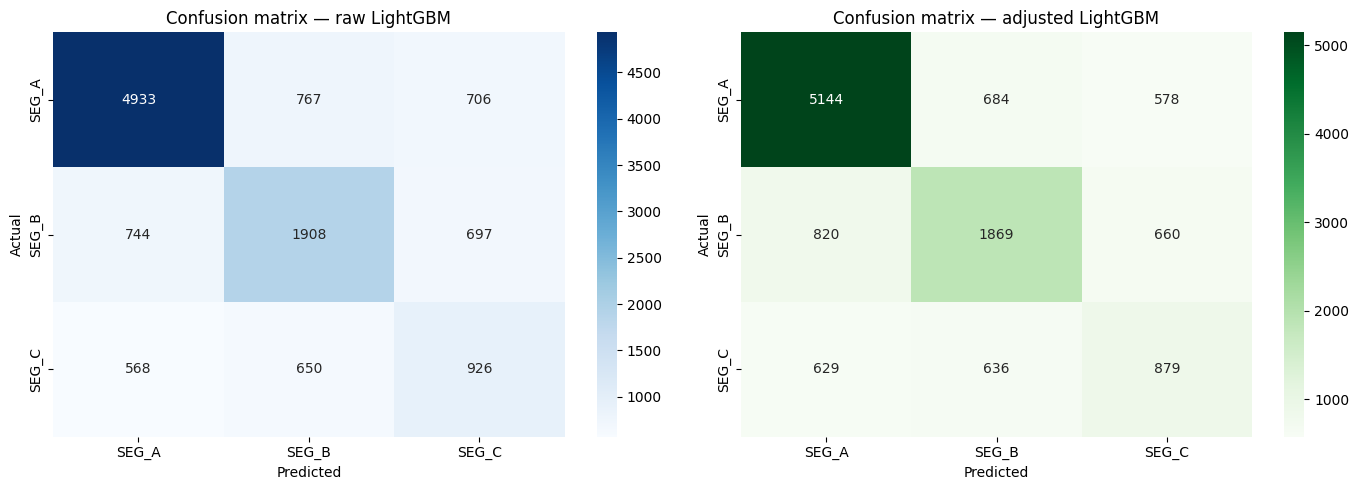

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_raw = confusion_matrix(model_df['ATSEG_HCP'], oof_df['pred_raw'], labels=class_names)
cm_adj = confusion_matrix(model_df['ATSEG_HCP'], oof_df['pred_adj'], labels=class_names)

sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=class_names, yticklabels=class_names)
axes[0].set_title('Confusion matrix — raw LightGBM')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_adj, annot=True, fmt='d', cmap='Greens', ax=axes[1], xticklabels=class_names, yticklabels=class_names)
axes[1].set_title('Confusion matrix — adjusted LightGBM')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(FIG_DIR / 'lightgbm_confusion_matrices.png', dpi=150)
plt.show()


In [57]:
print('Classification report — raw')
print(classification_report(model_df['ATSEG_HCP'], oof_df['pred_raw'], zero_division=0))
print('Classification report — adjusted')
print(classification_report(model_df['ATSEG_HCP'], oof_df['pred_adj'], zero_division=0))


Classification report — raw
              precision    recall  f1-score   support

       SEG_A       0.79      0.77      0.78      6406
       SEG_B       0.57      0.57      0.57      3349
       SEG_C       0.40      0.43      0.41      2144

    accuracy                           0.65     11899
   macro avg       0.59      0.59      0.59     11899
weighted avg       0.66      0.65      0.66     11899

Classification report — adjusted
              precision    recall  f1-score   support

       SEG_A       0.78      0.80      0.79      6406
       SEG_B       0.59      0.56      0.57      3349
       SEG_C       0.42      0.41      0.41      2144

    accuracy                           0.66     11899
   macro avg       0.59      0.59      0.59     11899
weighted avg       0.66      0.66      0.66     11899



## 10. Aggregate feature importance

In [58]:
feature_importance_df = pd.concat(feature_importance_frames, axis=0)
feature_importance_summary = (
    feature_importance_df.groupby('feature', as_index=False)['importance']
    .mean()
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
feature_importance_summary.to_csv(IMPORTANCE_PATH, index=False)
feature_importance_summary.head(25)


,feature,importance
0,N_CLMOTHERS__slope,"1,244.6000"
1,DIRECTMAIL__slope,"1,133.2000"
2,ORAL_TRX__slope,945.6000
3,UC_NRX__slope,865.2000
4,UC_TRX__slope,777.4000
5,UC_TRX__early4_mean,746.6000
6,UC_TRX__recent_vs_early,745.0000
7,UC_TRX_R4_16SUM__std,718.6000
8,UC_NRX__max,707.6000
9,DETAILS__mean,645.2000


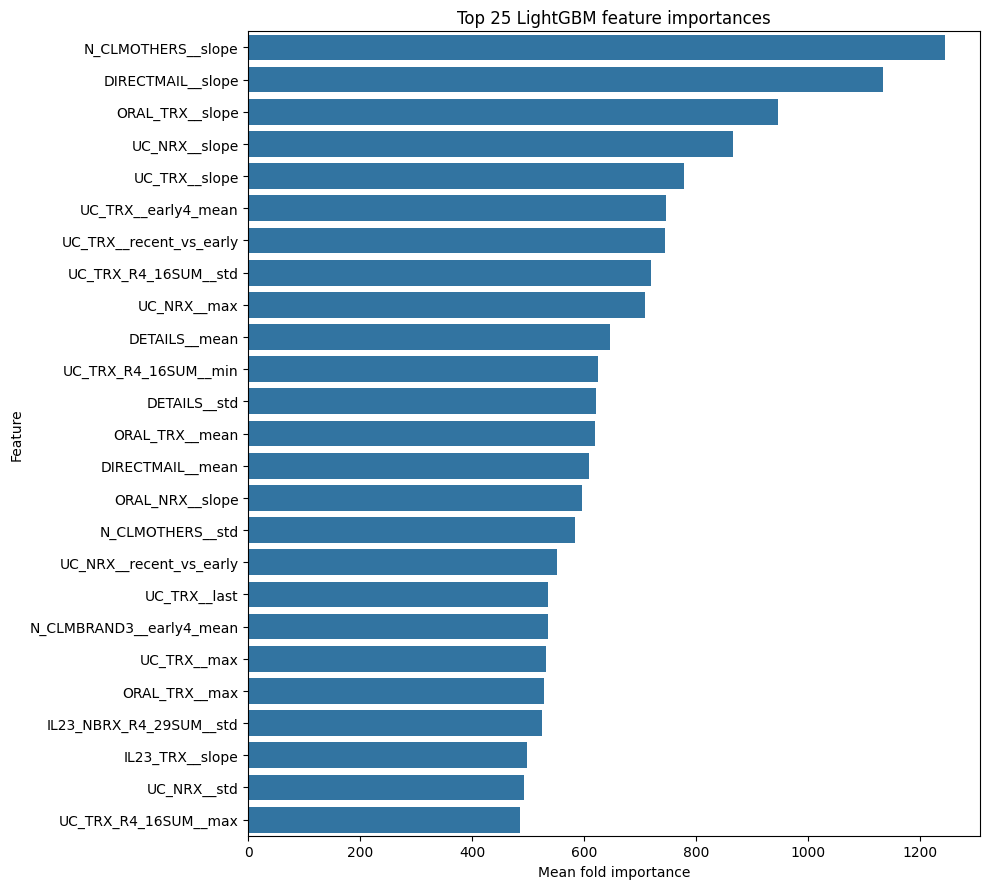

In [59]:
topn = 25
plt.figure(figsize=(10, 9))
sns.barplot(
    data=feature_importance_summary.head(topn),
    y='feature',
    x='importance'
)
plt.title(f'Top {topn} LightGBM feature importances')
plt.xlabel('Mean fold importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(FIG_DIR / 'lightgbm_top_feature_importance.png', dpi=150)
plt.show()


## 11. Fit the final LightGBM model on all labeled HCPs

In [60]:
final_estimator = fit_lightgbm(X, y_enc)

final_bundle = {
    'model_name': 'lightgbm_cost_sensitive',
    'estimator': final_estimator,
    'label_encoder': label_encoder,
    'feature_cols': feature_cols,
    'lightgbm_params': LGBM_PARAMS,
}
joblib.dump(final_bundle, MODEL_PATH)
print(f'Saved final model to: {MODEL_PATH}')


Saved final model to: data/modeling_lightgbm/lightgbm_final_model.joblib


## 12. Presentation summary

In [61]:
presentation_summary = {
    'model_presented': 'LightGBM only',
    'prediction_unit': 'HCP',
    'history_per_hcp': '86 weeks',
    'imbalance_strategy': 'balanced sample weights + class-scaling adjustment',
    'primary_metric': PRIMARY_METRIC,
    'raw_metrics': raw_metrics,
    'adjusted_metrics': adj_metrics,
    'class_scaling': dict(zip(class_names, best_alphas)),
}
presentation_summary


{'model_presented': 'LightGBM only',
 'prediction_unit': 'HCP',
 'history_per_hcp': '86 weeks',
 'imbalance_strategy': 'balanced sample weights + class-scaling adjustment',
 'primary_metric': 'macro_pr_auc',
 'raw_metrics': {'macro_pr_auc': 0.6211271404352259,
  'macro_f1': 0.5885567152748544,
  'mcc': 0.4247923359909884,
  'macro_precision': 0.5871140168579969,
  'macro_recall': 0.5905615365428072,
  'log_loss': 0.7868760640876585},
 'adjusted_metrics': {'macro_pr_auc': 0.6230869029945185,
  'macro_f1': 0.5919197259803596,
  'mcc': 0.43345444931708155,
  'macro_precision': 0.5938362634253941,
  'macro_recall': 0.5903518571131997,
  'log_loss': 0.7717598081411502},
 'class_scaling': {'SEG_A': 1.0, 'SEG_B': 0.85, 'SEG_C': 0.85}}